<a href="https://colab.research.google.com/github/queleandrade/Aprendizado-de-Maquina---Mestrado/blob/main/iris_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acurácia: 1.0


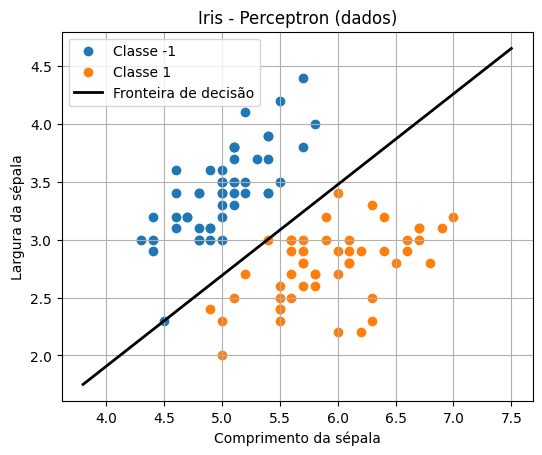

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# =========================================
# 1. Carregar o dataset Iris
# =========================================
iris = datasets.load_iris()

# Features: vamos usar apenas 2 (mais fácil de visualizar)
# índice 0 = comprimento da sépala
# índice 1 = largura da sépala
X = iris.data[:, [0, 1]]

# Target (classes)
y = iris.target

# =========================================
# 2. Transformar em problema binário
# =========================================
# Vamos usar apenas duas classes:
# 0 = Setosa
# 1 = Versicolor
X = X[y != 2]
y = y[y != 2]

# Converter classes para -1 e +1 (padrão do perceptron)
y = np.where(y == 0, -1, 1)

# =========================================
# 3. Classe Perceptron (do zero)
# =========================================
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Inicializar pesos e bias com zero
        self.w = np.zeros(n_features)
        self.b = 0

        # Treinamento
        for _ in range(self.n_iters):
            for i in range(n_samples):
                # Produto linear
                linear_output = np.dot(X[i], self.w) + self.b

                # Função de ativação (sinal)
                y_pred = np.sign(linear_output)

                # Atualização do perceptron
                if y[i] * y_pred <= 0:
                    self.w += self.lr * y[i] * X[i]
                    self.b += self.lr * y[i]

    def predict(self, X):
        linear_output = np.dot(X, self.w) + self.b
        return np.sign(linear_output)

# =========================================
# 4. Treinar o modelo
# =========================================
model = Perceptron(learning_rate=0.01, n_iters=1000)
model.fit(X, y)

# =========================================
# 5. Avaliação simples
# =========================================
predictions = model.predict(X)
accuracy = np.mean(predictions == y)

print("Acurácia:", accuracy)

# =========================================
# 6. Plot dos dados
# =========================================
plt.figure()

for classe in np.unique(y):
    plt.scatter(
        X[y == classe, 0],
        X[y == classe, 1],
        label=f"Classe {classe}"
    )

# --- RETA DE DECISÃO --- (:, 0) -> (todas as colunas, primeira coluna)
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5 #menor e maior valor de comprimento da sépala no dataset
x_vals = np.linspace(x_min, x_max, 200) #  gera pontos ao longo do eixo X cobrindo todo o gráfico

# w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b) / w[1] -> A reta de decisão do Perceptron
y_vals = -(model.w[0] * x_vals + model.b) / model.w[1] #calcula o valor de Y na fronteira usando a equação w·x + b = 0 isolando y

plt.plot(x_vals, y_vals, color='black', linewidth=2, label='Fronteira de decisão') #desenha  areta
# -----------------------

plt.xlabel("Comprimento da sépala")
plt.ylabel("Largura da sépala")
plt.title("Iris - Perceptron (dados)")
plt.legend()

plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)

plt.show()